In [12]:
#| default_exp core


In [23]:
#| export
from IPython.display import display, Image
from typing import Union

# Step 2: Grab photos from the camera

![Step 2 diagram](https://raw.githubusercontent.com/jaewilson07/bird-watcher/main/docs/diagrams/02-step.png)

**Goal:** connect to the phone camera, ask for one (or several) photos, save them to disk.

We build **two** functions that both belong to `bird_watcher/get_image.py`:

- `get_image_from_camera` — fetch one photo
- `get_images_from_camera` — fetch several, one every few seconds

Both land in `get_image.py` because they share the same `#| default_exp get_image` directive.

## Step 2.0 — Setup

when you look at a scripting project the first thing we always set is the .env file (environment)

the environment will have details that are specific to YOU.

In our case, you don't have my cell phone, so you have to set your own `PHONE_IP` otherwise this won't work.

Similarly if you're using online resources, it might ask for your password.  You don't want Jae's ROBLOX login, you need your ROBLOX password.

These details are set in a .env file and kept hidden (off of the internet)

In [14]:
import os

from dotenv import load_dotenv

assert load_dotenv()

# From config.yaml (or hardcoded fallback)
PHONE_IP = os.environ.get("PHONE_IP")

# use the assert validate if something is true.
assert PHONE_IP, "PHONE_IP environment variable is not set. Please set it in your .env file."

print(f"Using PHONE_IP: {PHONE_IP}")


Using PHONE_IP: 192.168.1.207


## Step 2.1 — The camera is just a web page

IP Webcam (the Android app) serves photos at `http://PHONE_IP:8080/photo.jpg`. Open that URL in a browser — you'll see a single JPEG. We can grab that same JPEG with Python.

the `requests` library allows us to send requests.  

In our case we are using a GET request to retrieve data from the IP Webcam app's internal website.

In [24]:
#| export

def get_image_from_ip_webcam(phone_ip, return_bytes: bool = False, debug_prn: bool = False) -> Union[bytes, Image]:
    import requests

    phone_url = f"http://{phone_ip}:8080/photo.jpg"

    if debug_prn:
        print(f"retrieving image from phone URL: {phone_url}")

    response = requests.get(phone_url, timeout=10)
    response.raise_for_status()

    if debug_prn:
        print(f"Retrieved {len(response.content)/1000} KB from phone camera.")

    if return_bytes:
        return response.content

    return Image(data=response.content)

retrieving image from phone URL: http://192.168.1.207:8080/photo.jpg
Retrieved 752.832 KB from phone camera.


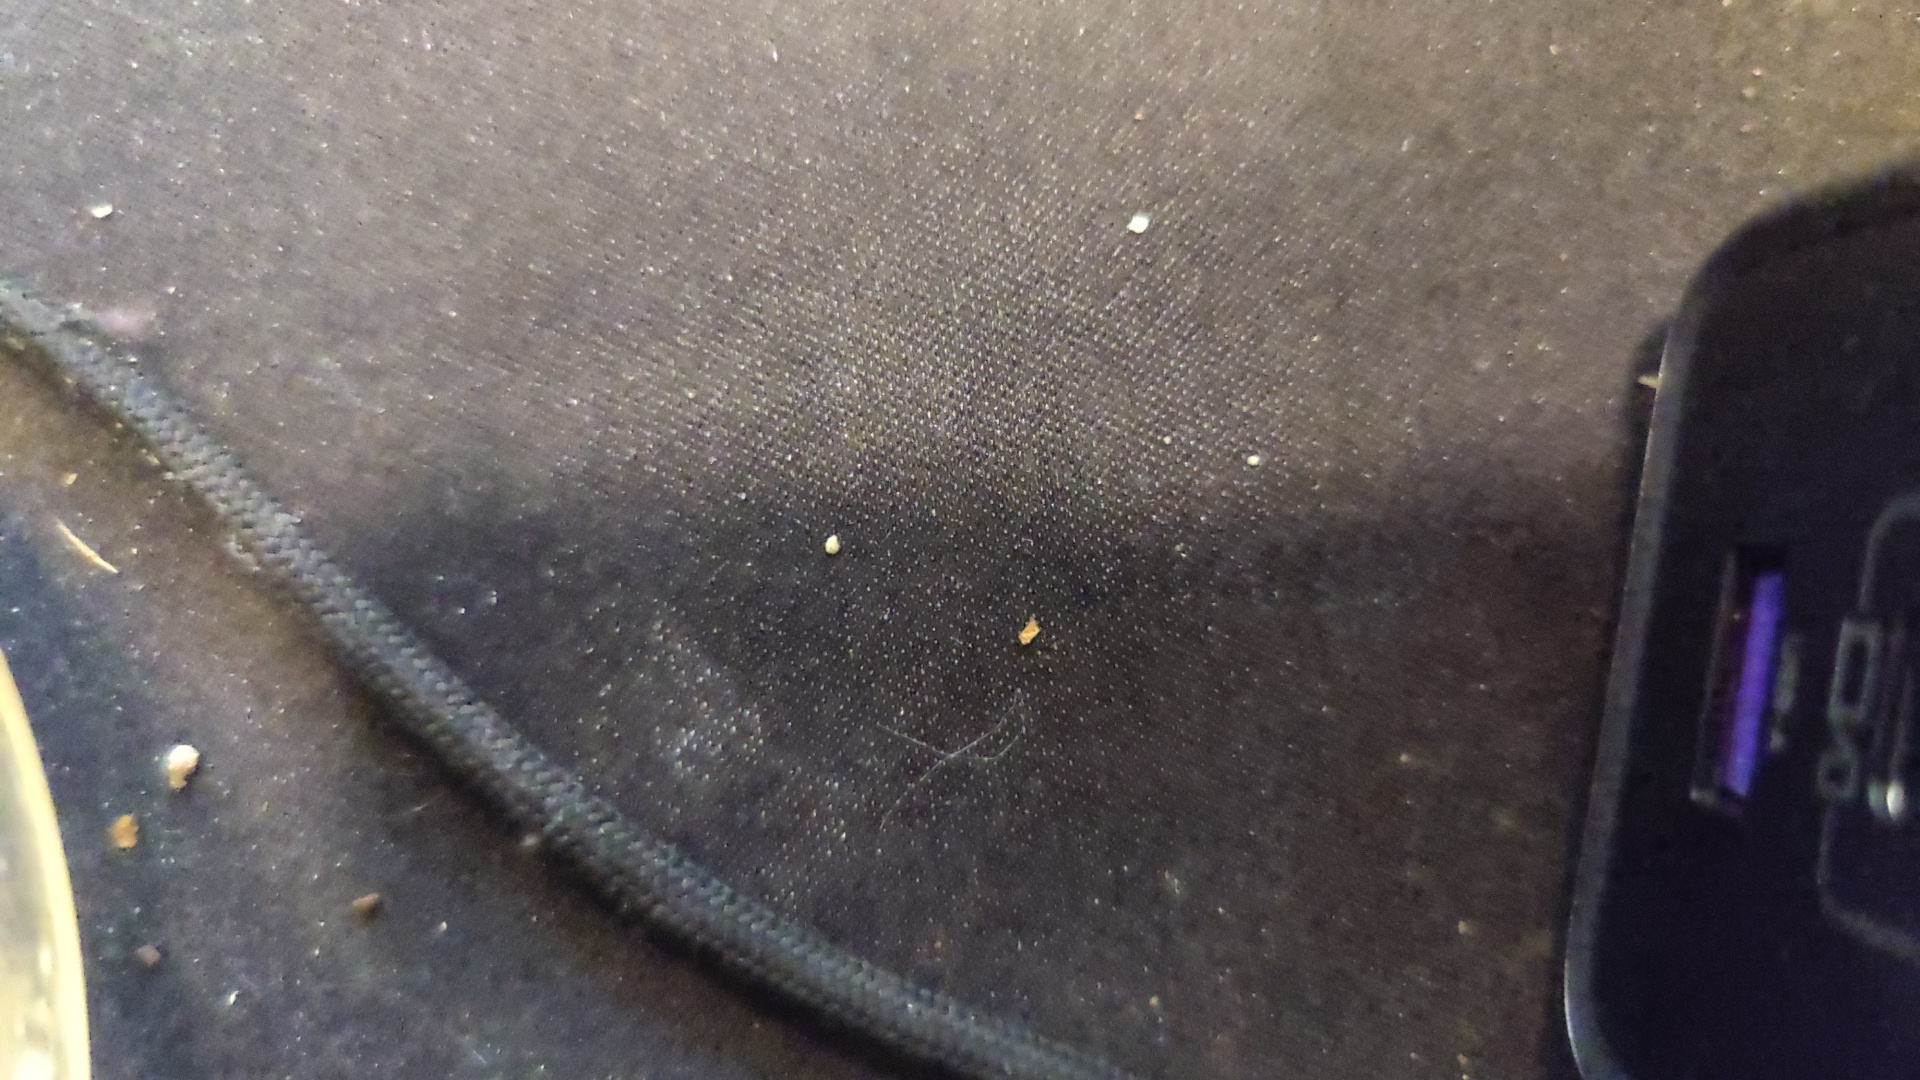

In [25]:
get_image_from_ip_webcam(PHONE_IP, debug_prn=True)

## Step 2.2 — Save the photo with a timestamped filename

We will use the current datetime to store the file in the data/samples folder.

Notice that in .gitignore the data/samples is ignored so we don't put it on the internet.  just like the .env file

In [26]:
#| export
def save_file_with_timestamp(content, filename: str, output_folder: str, debug_prn: bool = False):
    """
    Save the image content to a file with a timestamp in the filename.

    Args:
        content (bytes): The image content to save.
        filename (str): The base filename to use for saving the image.
        output_folder (str): The folder where the image will be saved.
        debug_prn (bool): Whether to print debug information.
    """
    import datetime as dt

    # Get the current timestamp
    timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")

    # Create the full filename with timestamp
    full_filename = f"{output_folder}/{timestamp}_{filename}.jpg"

    # Save the image content to the file
    with open(full_filename, "wb") as f:
        f.write(content)

    if debug_prn:
        print(f"Saved image to {full_filename}")
    
    return full_filename

retrieving image from phone URL: http://192.168.1.207:8080/photo.jpg
Retrieved 743.914 KB from phone camera.
Saved image to ../data/tests//20260708_090516_test_tutorial2.jpg


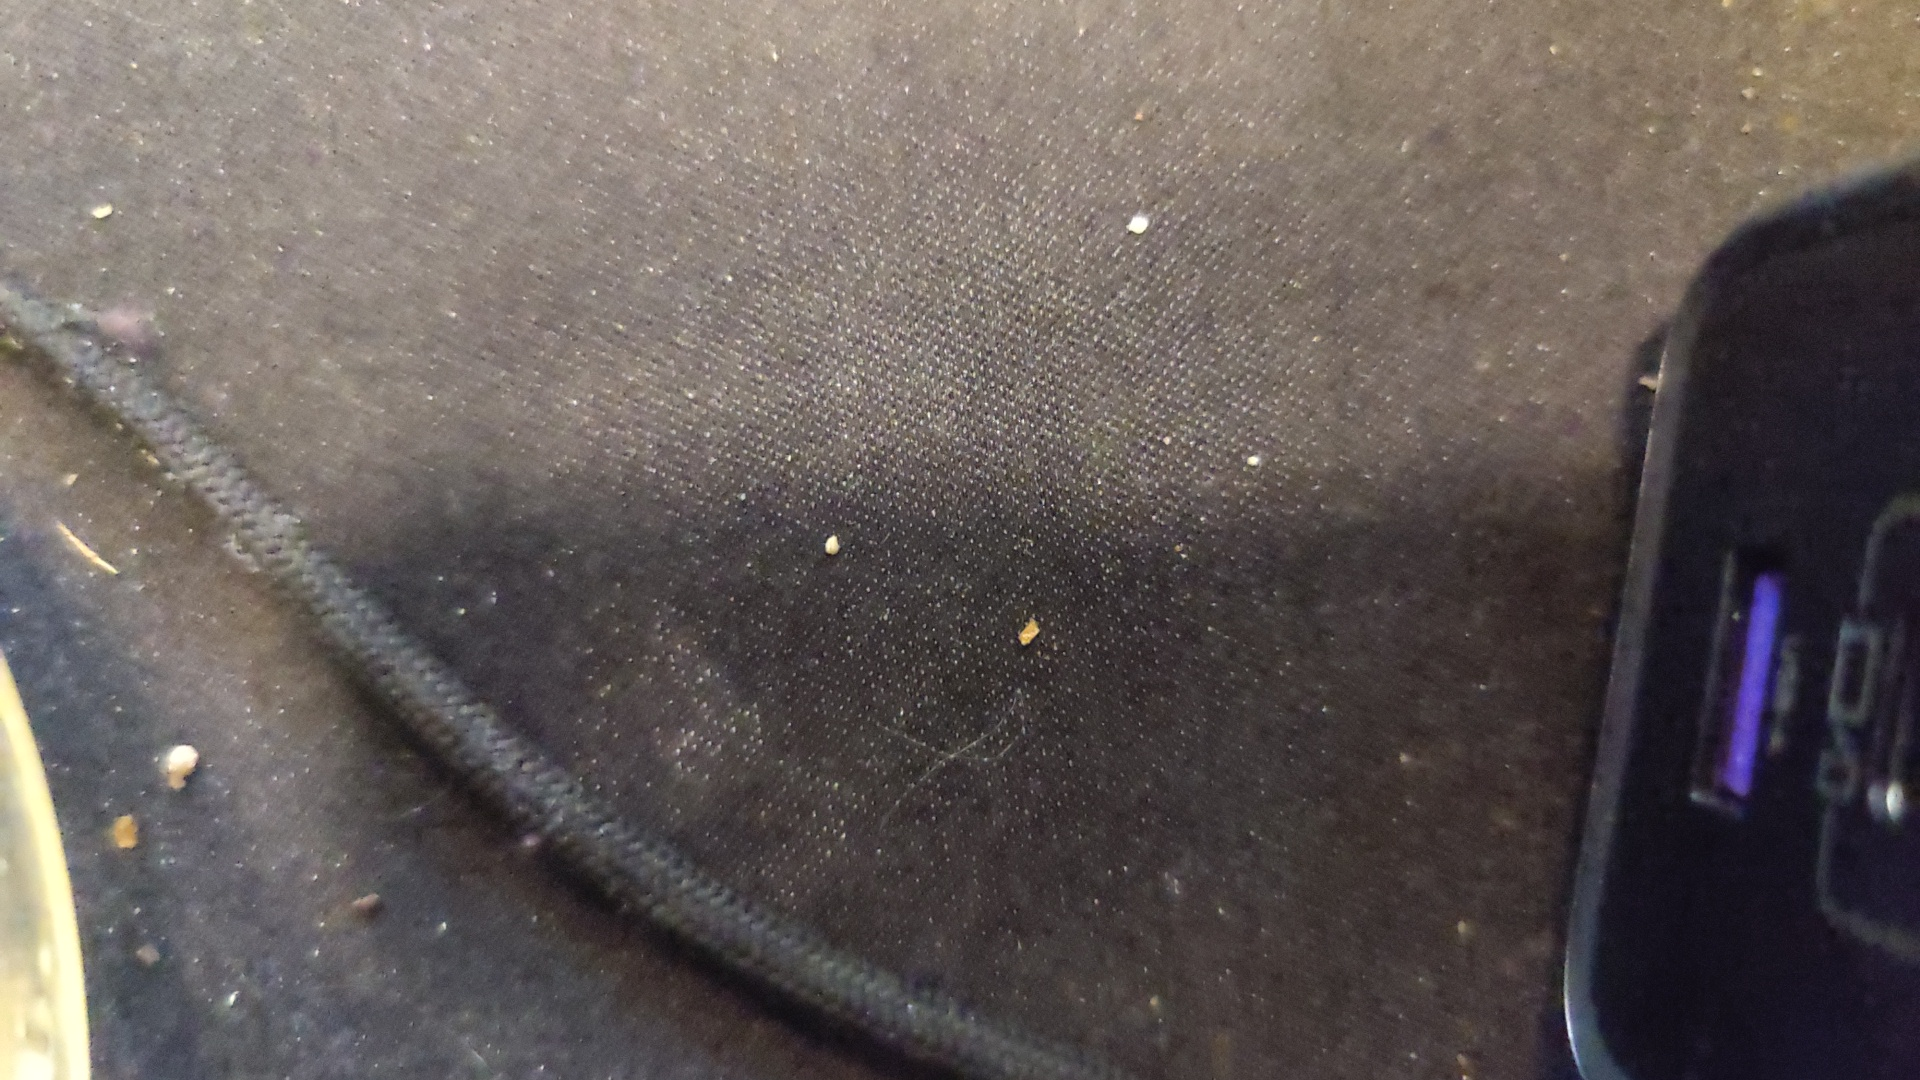

In [31]:
from IPython.display import display

OUTPUT_FOLDER = '../data/tests/'

if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

phone_image = get_image_from_ip_webcam(PHONE_IP, return_bytes=True, debug_prn=True)

img_path = save_file_with_timestamp(content = phone_image, 
                          filename="test_tutorial2",
                          output_folder=OUTPUT_FOLDER,
                          debug_prn=True)

Image(filename = img_path)

## Step 2.3 — Define `get_image_from_camera`

We use functions to keep it DRY (Don't Repeat Yourself)

- If there is consistent behavior we can wrap it in a function.

- Functions also make it so you don't have to remember complex steps. 

- And the simple name of a function should make your code easier to read and understand.


Why would i write `get_image_from_ip_webcam` as a separate function from `save_file_with_timestamp` -- hint, are there other reasons i might save a file or other places I might source images from?


In [44]:
#| export

def get_image_from_camera(
    camera_url: str,
    file_name = None,
    output_folder = None,
    debug_prn: bool = False
) -> str:
    """Grab one photo from the camera.

    Args:
        camera_url: where to ask for a photo. Usually `http://PHONE_IP:8080/photo.jpg`.
        timeout_seconds: how long to wait before giving up.
        file_name: the name to use for the saved file.
        output_folder: the folder where the image will be saved.

    Returns:
        Path to the saved JPEG or the image content as bytes if not saved.
    """

    content = get_image_from_ip_webcam(camera_url, return_bytes= True, debug_prn=debug_prn)

    if file_name and output_folder:
        file_path = save_file_with_timestamp(content=content, filename=file_name, output_folder=output_folder)
        if debug_prn:
            print(f"Saved image to {file_path}")
        return file_path
    else:
        if debug_prn:
            print(f"Retrieved {len(content)/1000} KB from camera.")
        return content



retrieving image from phone URL: http://192.168.1.207:8080/photo.jpg
Retrieved 693.853 KB from phone camera.
Retrieved 693.853 KB from camera.


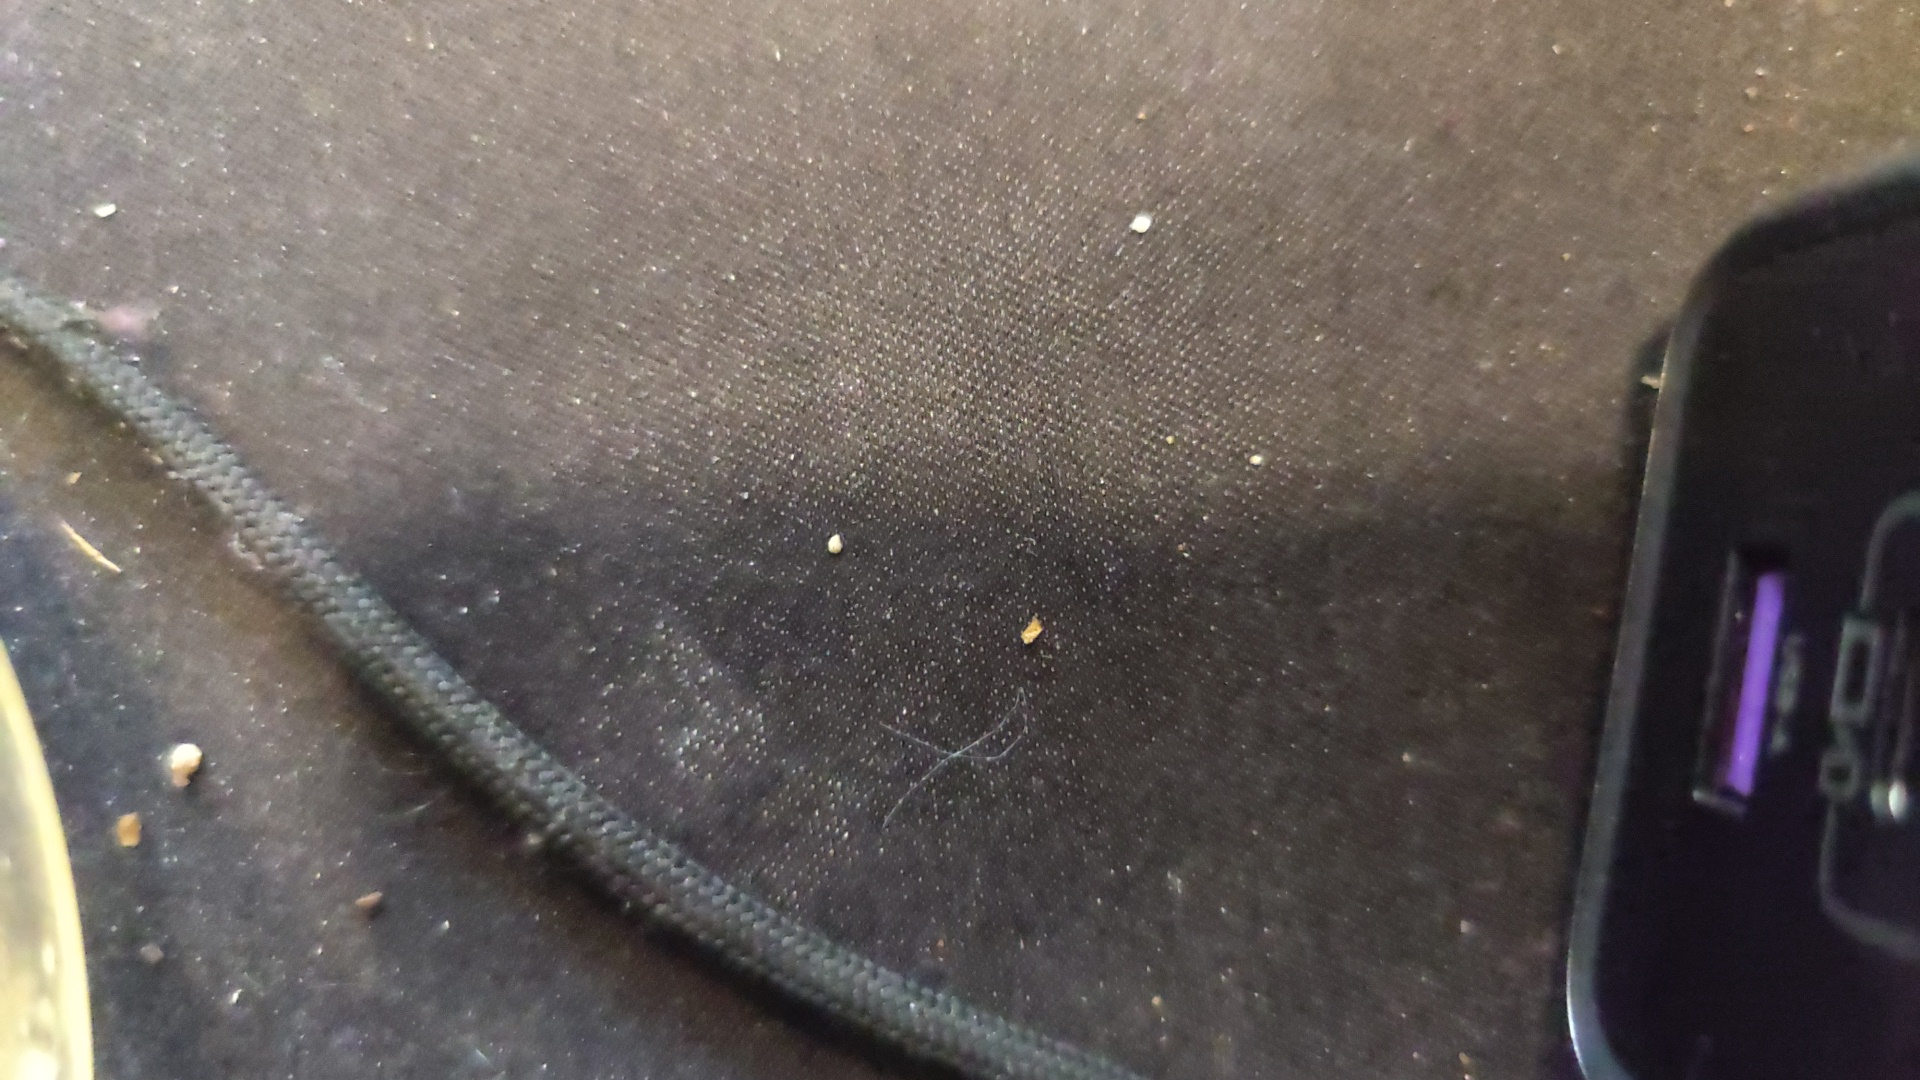

In [45]:
from IPython.display import Image, display

# if i don't pass file_name and output_folder, it will return the image content as bytes
my_image = get_image_from_camera(PHONE_IP, debug_prn=True)

display(Image(data = my_image))

retrieving image from phone URL: http://192.168.1.207:8080/photo.jpg
Retrieved 737.921 KB from phone camera.
Saved image to ../data/tests//20260708_090933_tutorial2_test_save.jpg


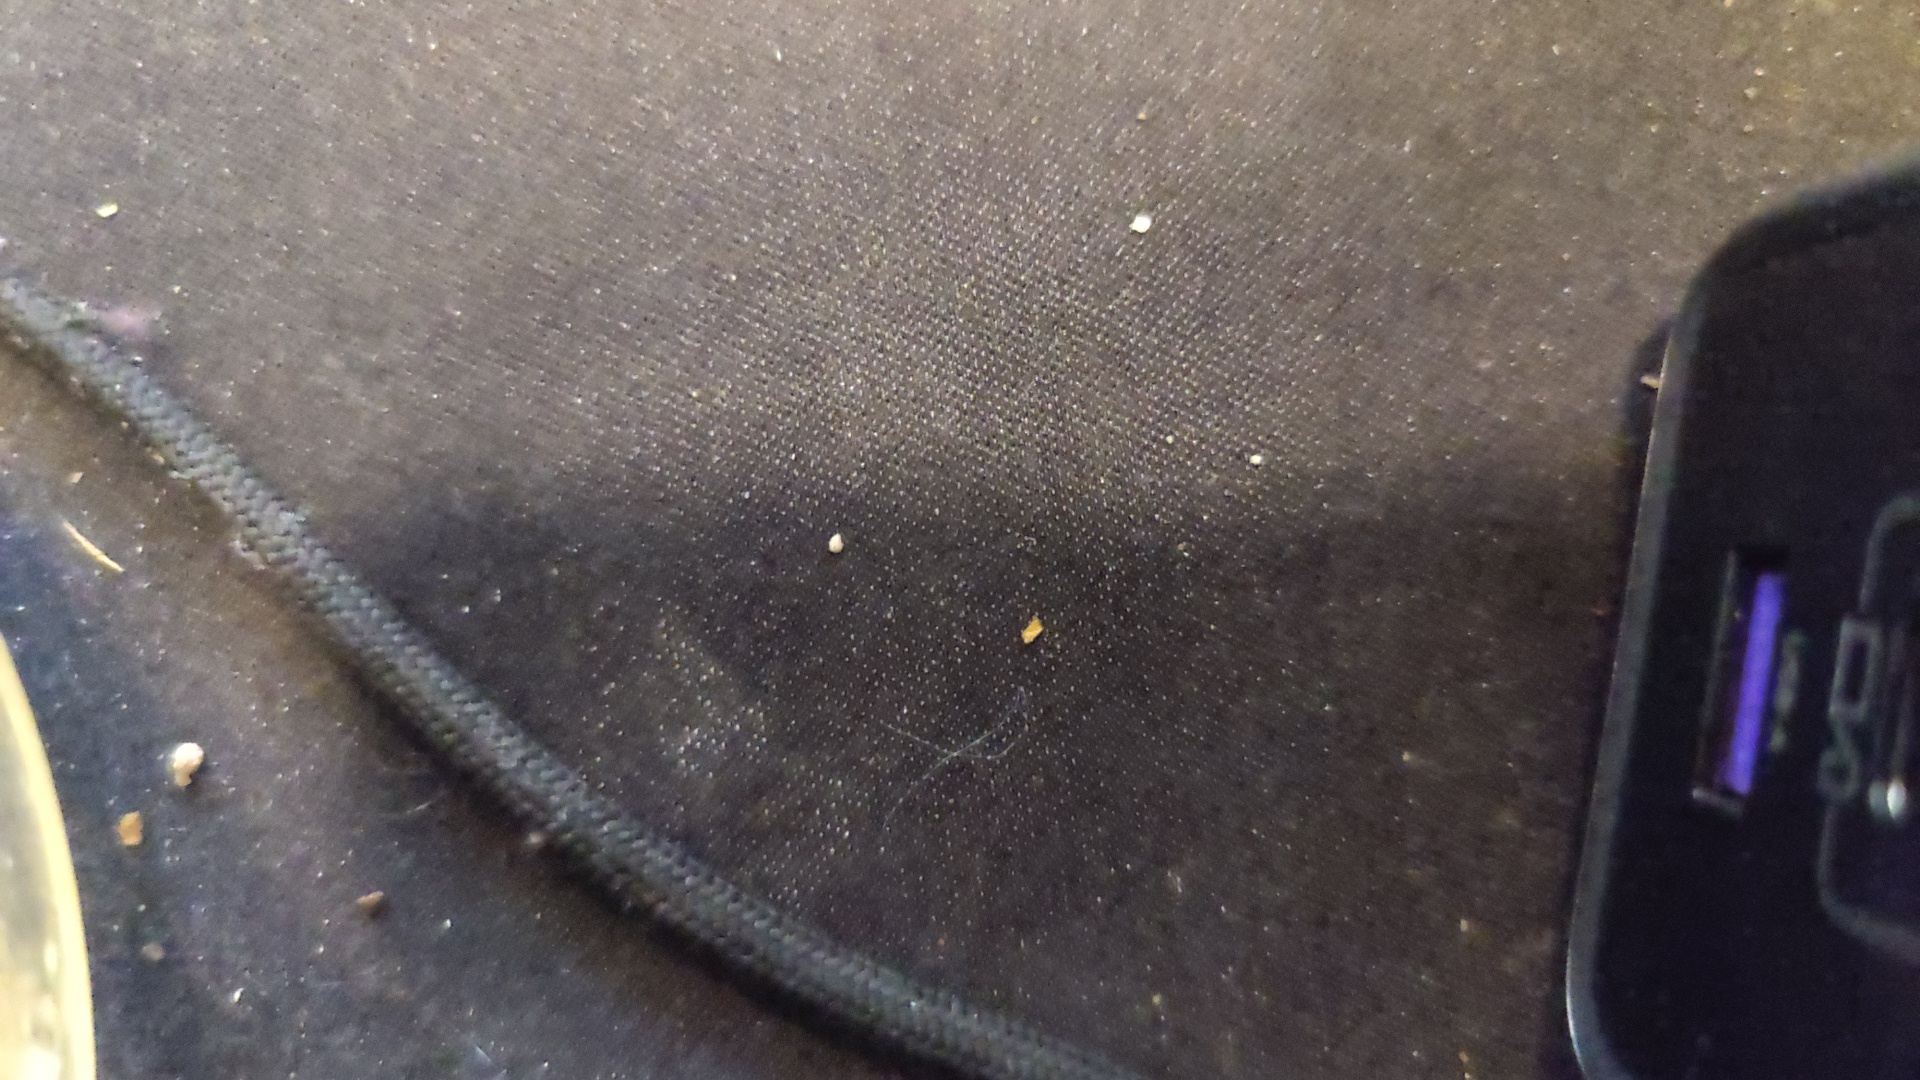

In [ ]:
from IPython.display import Image, display

# if i pass file_name and output_folder, it will save the image and return the file path
file_name = get_image_from_camera(
    PHONE_IP,
    file_name="tutorial2_test_save",
    output_folder=OUTPUT_FOLDER,
    debug_prn=True
    )

display(Image(filename=file_name))

## What's next

**Step 3:** open [03-poll.ipynb](03-poll.ipynb) — we *use* both functions and learn the polling pattern (frames, sleep, KeyboardInterrupt).